# 08 - Experimental LDA + LSTM Classifier

This notebook is an **experimental comparison** for document classification.

Non-generative compliance:
- No generative AI.
- LDA is used only for topic modeling.
- LSTM is used only for supervised classification.
- No prompting, no text generation.


## 1) Repository Inspection and Existing Assets

We inspect the repository first and reuse existing infrastructure.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('PROJECT_ROOT:', PROJECT_ROOT)
for name in ['notebooks', 'src', 'data/processed', 'data/interim', 'models', 'outputs', 'reports']:
    path = PROJECT_ROOT / name
    print('\n===', name, '===')
    if not path.exists():
        print('Missing:', path)
        continue
    items = sorted([p.name for p in path.iterdir()])
    for it in items[:40]:
        print('-', it)
    if len(items) > 40:
        print('... (', len(items)-40, 'more )')


PROJECT_ROOT: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification

=== notebooks ===
- 00_dataset_download_and_preparation.ipynb
- 01_ocr_pipeline_build_and_validation.ipynb
- 02_ocr_text_plus_layout_features.ipynb
- 02b_confusion_pair_improvement.ipynb
- 05_invoice_extraction_and_evaluation.ipynb
- 07_bert_random_forest.ipynb
- 08_lda_lstm_classifier.ipynb
- data
- outputs

=== src ===
- __init__.py
- __pycache__
- config.py
- evaluation.py
- image_preprocessing.py
- invoice_extraction.py
- invoice_rules.py
- layout_features.py
- models_bert_rf.py
- models_layout.py
- models_lda_lstm.py
- ocr_engine.py
- utils.py
- validators.py
- zones.py

=== data/processed ===
- class_balance_by_split.csv
- dataset_summary.json
- duplicates_by_hash.csv
- duplicates_by_relative_path.csv
- five_class_subset
- metadata_all.csv
- metadata_five_classes.csv
- test.csv
- train.csv
- val.csv

=== data/interim ===
- bert_embeddings
- layout_features
- ocr
- ocr_mode

## 2) Objective

Build a classifier for classes:
- invoice, form, resume, email, budget

Pipeline:
1. OCR text from shared cache
2. LDA topic vectors (fit on train only)
3. LSTM sequence classifier
4. Fuse LSTM representation with LDA topics


## 3) Imports and Setup


In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_ocr_config
from src.ocr_engine import load_ocr_text
from src.evaluation import (
    compute_metrics,
    metrics_dict_to_frame,
    confusion_matrix_df,
    classification_report_df,
    plot_confusion_matrix,
)
from src.models_lda_lstm import (
    normalize_ocr_text,
    fit_lda_vectorizer,
    transform_lda_vectorizer,
    fit_lda_model,
    transform_topics,
    label_to_index,
    index_to_label,
    build_prediction_table,
    save_json,
    save_artifact,
)


In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

LABELS = ['invoice', 'form', 'resume', 'email', 'budget']

cfg = load_ocr_config(PROJECT_ROOT / 'configs' / 'config.yaml')
cfg.cache_dir = str(PROJECT_ROOT / 'data' / 'interim' / 'ocr')

models_dir = PROJECT_ROOT / 'models' / 'experimental'
lstm_dir = models_dir / 'lstm_classifier'
pred_dir = PROJECT_ROOT / 'outputs' / 'predictions'
fig_dir = PROJECT_ROOT / 'reports' / 'figures'
table_dir = PROJECT_ROOT / 'reports' / 'tables'
interim_dir = PROJECT_ROOT / 'data' / 'interim' / 'lda_lstm'

for p in [models_dir, lstm_dir, pred_dir, fig_dir, table_dir, interim_dir]:
    p.mkdir(parents=True, exist_ok=True)


## 4) Load Train/Val/Test Metadata


In [4]:
train_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'train.csv')
val_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'val.csv')
test_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'test.csv')

required_cols = {'doc_id', 'file_path', 'class_name'}
for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'{split_name}.csv missing required columns: {missing}')
    if 'split' not in df.columns:
        df['split'] = split_name

print('sizes:', len(train_df), len(val_df), len(test_df))


sizes: 8777 1882 1881


## 5) Load OCR Text from Shared OCR Cache


In [5]:
def attach_ocr_text(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['ocr_text'] = out['doc_id'].map(lambda d: load_ocr_text(d, cfg=cfg))
    out['ocr_text'] = out['ocr_text'].fillna('').astype(str)
    out['ocr_text'] = out['ocr_text'].map(normalize_ocr_text)
    return out

train_text_df = attach_ocr_text(train_df)
val_text_df = attach_ocr_text(val_df)
test_text_df = attach_ocr_text(test_df)

print('empty OCR ratios:',
      round((train_text_df['ocr_text'].str.len() == 0).mean(), 4),
      round((val_text_df['ocr_text'].str.len() == 0).mean(), 4),
      round((test_text_df['ocr_text'].str.len() == 0).mean(), 4))


empty OCR ratios: 0.0014 0.0011 0.0021


## 6) Text Preprocessing for LDA and LSTM

- lowercase + whitespace normalization already applied
- LDA uses vectorizer tokenization with stopword removal
- LSTM uses train-only tokenizer/vocabulary


In [6]:
y_train = train_text_df['class_name'].values
y_val = val_text_df['class_name'].values
y_test = test_text_df['class_name'].values

y_train_idx = label_to_index(LABELS, y_train)
y_val_idx = label_to_index(LABELS, y_val)
y_test_idx = label_to_index(LABELS, y_test)


## 7) Fit LDA on Training Text Only


In [7]:
vectorizer, X_count_train = fit_lda_vectorizer(
    train_text_df['ocr_text'].tolist(),
    min_df=3,
    max_df=0.95,
    max_features=30000,
    ngram_range=(1, 2),
)

X_count_val = transform_lda_vectorizer(vectorizer, val_text_df['ocr_text'].tolist())
X_count_test = transform_lda_vectorizer(vectorizer, test_text_df['ocr_text'].tolist())

from sklearn.linear_model import LogisticRegression

topic_candidates = [10, 20, 30, 40]
lda_search_rows = []
best_lda = None

for n_topics in topic_candidates:
    lda = fit_lda_model(X_count_train, n_topics=n_topics, random_state=RANDOM_STATE, max_iter=20)
    T_train = transform_topics(lda, X_count_train)
    T_val = transform_topics(lda, X_count_val)

    # Validation-only topic count selection via downstream linear probe.
    probe = LogisticRegression(max_iter=2000, solver='lbfgs', multi_class='auto')
    probe.fit(T_train, y_train)
    yv = probe.predict(T_val)
    m = compute_metrics(y_val, yv, LABELS)

    row = {
        'n_topics': n_topics,
        'val_macro_f1_probe': m['macro_f1'],
        'val_invoice_recall_probe': m['invoice_recall'],
    }
    lda_search_rows.append(row)

    if best_lda is None or m['macro_f1'] > best_lda['macro_f1']:
        best_lda = {'model': lda, 'n_topics': n_topics, 'macro_f1': m['macro_f1']}

lda_search_df = pd.DataFrame(lda_search_rows).sort_values('val_macro_f1_probe', ascending=False)
lda_search_df


/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default

,n_topics,val_macro_f1_probe,val_invoice_recall_probe
3,40,0.793005,0.711590
2,30,0.779443,0.646900
1,20,0.771670,0.684636
0,10,0.697340,0.614555


## 8) Create Topic Features for All Splits


In [8]:
lda_model = best_lda['model']
print('Selected n_topics:', best_lda['n_topics'])

T_train = transform_topics(lda_model, X_count_train)
T_val = transform_topics(lda_model, X_count_val)
T_test = transform_topics(lda_model, X_count_test)

print('Topic matrix shapes:', T_train.shape, T_val.shape, T_test.shape)

# Save topic distributions for auditability.
for split_name, df_meta, topics in [
    ('train', train_text_df, T_train),
    ('val', val_text_df, T_val),
    ('test', test_text_df, T_test),
]:
    topic_cols = [f'topic_{i:02d}' for i in range(topics.shape[1])]
    tmp = pd.DataFrame(topics, columns=topic_cols)
    tmp.insert(0, 'doc_id', df_meta['doc_id'].values)
    tmp.to_csv(interim_dir / f'{split_name}_topic_vectors.csv', index=False)


Selected n_topics: 40
Topic matrix shapes: (8777, 40) (1882, 40) (1881, 40)


## 9) Build and Train LSTM Classifier

We support TensorFlow/Keras first, with PyTorch fallback.
If neither is available, notebook fails with a clear error.


In [9]:
HAS_TF = False
HAS_TORCH = False

try:
    import tensorflow as tf
    HAS_TF = True
except Exception:
    HAS_TF = False

if not HAS_TF:
    try:
        import torch
        import torch.nn as nn
        import torch.optim as optim
        from torch.utils.data import Dataset, DataLoader
        HAS_TORCH = True
    except Exception:
        HAS_TORCH = False

print('HAS_TF=', HAS_TF, 'HAS_TORCH=', HAS_TORCH)
if not (HAS_TF or HAS_TORCH):
    raise ImportError('Neither TensorFlow/Keras nor PyTorch is available. Install one backend to run this notebook.')


/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


HAS_TF= True HAS_TORCH= False


In [10]:
VOCAB_SIZE = 30000
MAX_LEN = 220
EMBED_DIM = 128
LSTM_UNITS = 64
BATCH_SIZE = 64
EPOCHS = 12
DROPOUT = 0.25

if HAS_TF:
    tf.random.set_seed(RANDOM_STATE)

    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Dropout, Concatenate
    from tensorflow.keras.models import Model

    tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='[OOV]')
    tokenizer.fit_on_texts(train_text_df['ocr_text'].tolist())

    X_seq_train = pad_sequences(tokenizer.texts_to_sequences(train_text_df['ocr_text'].tolist()), maxlen=MAX_LEN, padding='post', truncating='post')
    X_seq_val = pad_sequences(tokenizer.texts_to_sequences(val_text_df['ocr_text'].tolist()), maxlen=MAX_LEN, padding='post', truncating='post')
    X_seq_test = pad_sequences(tokenizer.texts_to_sequences(test_text_df['ocr_text'].tolist()), maxlen=MAX_LEN, padding='post', truncating='post')

    seq_input = Input(shape=(MAX_LEN,), name='seq_input')
    topic_input = Input(shape=(T_train.shape[1],), name='topic_input')

    x = Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN)(seq_input)
    x = Bidirectional(LSTM(LSTM_UNITS))(x)
    x = Dropout(DROPOUT)(x)

    z = Concatenate()([x, topic_input])
    z = Dense(128, activation='relu')(z)
    z = Dropout(DROPOUT)(z)
    out = Dense(len(LABELS), activation='softmax')(z)

    model = Model(inputs=[seq_input, topic_input], outputs=out)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    hist = model.fit(
        [X_seq_train, T_train], y_train_idx,
        validation_data=([X_seq_val, T_val], y_val_idx),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es],
        verbose=1,
    )

    p_val = model.predict([X_seq_val, T_val], verbose=0)
    p_test = model.predict([X_seq_test, T_test], verbose=0)

    y_val_pred_idx = p_val.argmax(axis=1)
    y_test_pred_idx = p_test.argmax(axis=1)

    y_val_pred = np.array(index_to_label(LABELS, y_val_pred_idx))
    y_test_pred = np.array(index_to_label(LABELS, y_test_pred_idx))

    # Save TF artifacts
    model.save(lstm_dir / 'keras_model.keras')
    tok_json = tokenizer.to_json()
    (lstm_dir / 'tokenizer.json').write_text(tok_json, encoding='utf-8')

else:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader

    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    def tokenize_simple(text):
        return [tok for tok in text.split() if tok]

    # Train-only vocabulary
    freq = {}
    for t in train_text_df['ocr_text'].tolist():
        for tok in tokenize_simple(t):
            freq[tok] = freq.get(tok, 0) + 1

    vocab_sorted = sorted(freq.items(), key=lambda x: x[1], reverse=True)
    vocab_tokens = [w for w, _ in vocab_sorted[: VOCAB_SIZE - 2]]
    word2idx = {'[PAD]': 0, '[OOV]': 1}
    for i, w in enumerate(vocab_tokens, start=2):
        word2idx[w] = i

    def texts_to_padded(texts):
        arr = np.zeros((len(texts), MAX_LEN), dtype=np.int64)
        for i, t in enumerate(texts):
            toks = tokenize_simple(t)
            idxs = [word2idx.get(tok, 1) for tok in toks[:MAX_LEN]]
            arr[i, :len(idxs)] = np.array(idxs, dtype=np.int64)
        return arr

    X_seq_train = texts_to_padded(train_text_df['ocr_text'].tolist())
    X_seq_val = texts_to_padded(val_text_df['ocr_text'].tolist())
    X_seq_test = texts_to_padded(test_text_df['ocr_text'].tolist())

    class TopicSeqDataset(Dataset):
        def __init__(self, seq, topics, y):
            self.seq = torch.tensor(seq, dtype=torch.long)
            self.topics = torch.tensor(topics, dtype=torch.float32)
            self.y = torch.tensor(y, dtype=torch.long)
        def __len__(self):
            return len(self.y)
        def __getitem__(self, idx):
            return self.seq[idx], self.topics[idx], self.y[idx]

    class LdaLstmNet(nn.Module):
        def __init__(self, vocab_size, embed_dim, lstm_units, topic_dim, n_classes, dropout=0.25):
            super().__init__()
            self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            self.lstm = nn.LSTM(embed_dim, lstm_units, batch_first=True, bidirectional=True)
            self.drop = nn.Dropout(dropout)
            self.fc1 = nn.Linear((2 * lstm_units) + topic_dim, 128)
            self.fc2 = nn.Linear(128, n_classes)
        def forward(self, seq, topics):
            x = self.emb(seq)
            _, (h, _) = self.lstm(x)
            h_cat = torch.cat([h[0], h[1]], dim=1)
            z = torch.cat([h_cat, topics], dim=1)
            z = self.drop(torch.relu(self.fc1(z)))
            return self.fc2(z)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    train_ds = TopicSeqDataset(X_seq_train, T_train, y_train_idx)
    val_ds = TopicSeqDataset(X_seq_val, T_val, y_val_idx)
    test_ds = TopicSeqDataset(X_seq_test, T_test, y_test_idx)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = LdaLstmNet(VOCAB_SIZE, EMBED_DIM, LSTM_UNITS, T_train.shape[1], len(LABELS), DROPOUT).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    best_state = None
    best_val_loss = 1e9
    patience = 2
    bad_epochs = 0

    for epoch in range(EPOCHS):
        model.train()
        for seq_b, topic_b, y_b in train_loader:
            seq_b, topic_b, y_b = seq_b.to(device), topic_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(seq_b, topic_b)
            loss = criterion(logits, y_b)
            loss.backward()
            optimizer.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for seq_b, topic_b, y_b in val_loader:
                seq_b, topic_b, y_b = seq_b.to(device), topic_b.to(device), y_b.to(device)
                logits = model(seq_b, topic_b)
                val_losses.append(criterion(logits, y_b).item())

        mean_val = float(np.mean(val_losses)) if val_losses else 999.0
        print('epoch', epoch + 1, 'val_loss', round(mean_val, 4))

        if mean_val < best_val_loss:
            best_val_loss = mean_val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print('Early stopping.')
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    def predict_proba(loader):
        model.eval()
        probs = []
        with torch.no_grad():
            for seq_b, topic_b, _ in loader:
                seq_b, topic_b = seq_b.to(device), topic_b.to(device)
                logits = model(seq_b, topic_b)
                p = torch.softmax(logits, dim=1).cpu().numpy()
                probs.append(p)
        return np.vstack(probs)

    p_val = predict_proba(val_loader)
    p_test = predict_proba(test_loader)

    y_val_pred_idx = p_val.argmax(axis=1)
    y_test_pred_idx = p_test.argmax(axis=1)

    y_val_pred = np.array(index_to_label(LABELS, y_val_pred_idx))
    y_test_pred = np.array(index_to_label(LABELS, y_test_pred_idx))

    # Save Torch artifacts
    torch.save(model.state_dict(), lstm_dir / 'torch_model.pt')
    save_json(word2idx, lstm_dir / 'word2idx.json')


Epoch 1/12


/Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/.venv/lib/python3.9/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


138/138 ━━━━━━━━━━━━━━━━━━━━ 30s 202ms/step - accuracy: 0.5139 - loss: 1.1971 - val_accuracy: 0.7864 - val_loss: 0.5992
Epoch 2/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 193ms/step - accuracy: 0.8158 - loss: 0.4945 - val_accuracy: 0.8108 - val_loss: 0.5105
Epoch 3/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 29s 208ms/step - accuracy: 0.9015 - loss: 0.2648 - val_accuracy: 0.8061 - val_loss: 0.5763
Epoch 4/12
138/138 ━━━━━━━━━━━━━━━━━━━━ 27s 193ms/step - accuracy: 0.9512 - loss: 0.1499 - val_accuracy: 0.7763 - val_loss: 0.8005


## 10) Optional Fusion Note

Fusion is active in this implementation:
- sequence representation from LSTM
- topic vector from LDA
- concatenation before final dense classifier


## 11) Validation Evaluation


In [11]:
val_metrics = compute_metrics(y_val, y_val_pred, LABELS)
metrics_dict_to_frame(val_metrics, 'lda_lstm', 'val')


,model_name,split,accuracy,macro_f1,weighted_f1,precision_invoice,recall_invoice,precision_form,recall_form,precision_resume,recall_resume,precision_email,recall_email,precision_budget,recall_budget,invoice_precision,invoice_recall
0,lda_lstm,val,0.81084,0.80931,0.810175,0.794326,0.603774,0.677419,0.781915,0.989071,0.950131,0.904393,0.925926,0.716707,0.787234,0.794326,0.603774


## 12) Final Test Evaluation


In [12]:
test_metrics = compute_metrics(y_test, y_test_pred, LABELS)
metrics_dict_to_frame(test_metrics, 'lda_lstm', 'test')


,model_name,split,accuracy,macro_f1,weighted_f1,precision_invoice,recall_invoice,precision_form,recall_form,precision_resume,recall_resume,precision_email,recall_email,precision_budget,recall_budget,invoice_precision,invoice_recall
0,lda_lstm,test,0.809676,0.808874,0.809537,0.812734,0.583333,0.650964,0.808511,0.98338,0.934211,0.941489,0.938992,0.714634,0.779255,0.812734,0.583333


## 13) Confusion Matrix and Classification Report


,invoice,form,resume,email,budget
invoice,217,82,1,2,70
form,21,304,4,12,35
resume,2,12,355,5,6
email,1,15,1,354,6
budget,26,54,0,3,293


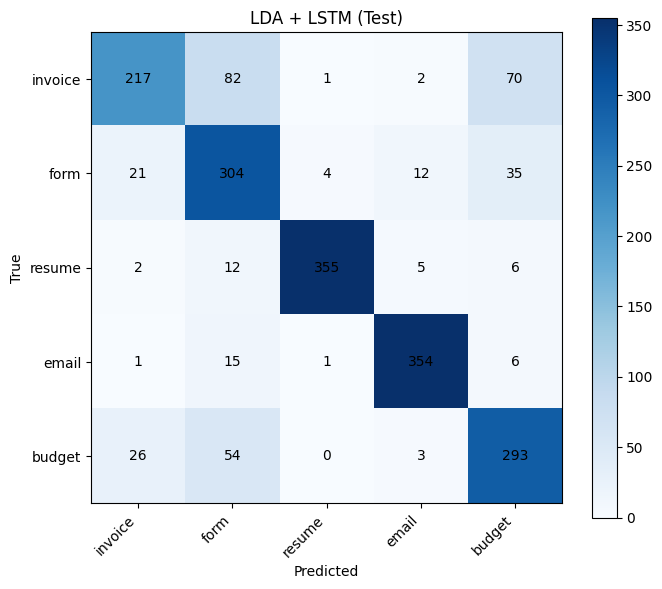

In [13]:
cm = confusion_matrix_df(y_test, y_test_pred, LABELS)
plot_confusion_matrix(cm, 'LDA + LSTM (Test)', save_path=fig_dir / 'lda_lstm_confusion_matrix.png')
cm


In [14]:
classification_report_df(y_test, y_test_pred, LABELS)


,precision,recall,f1-score,support
invoice,0.812734,0.583333,0.679186,372.000000
form,0.650964,0.808511,0.721234,376.000000
resume,0.983380,0.934211,0.958165,380.000000
email,0.941489,0.938992,0.940239,377.000000
budget,0.714634,0.779255,0.745547,376.000000
accuracy,0.809676,0.809676,0.809676,0.809676
macro avg,0.820640,0.808860,0.808874,1881.000000
weighted avg,0.821067,0.809676,0.809537,1881.000000


## 14) Invoice Recall Comparison


In [15]:
comparison_rows = [
    {'model_name': 'lda_lstm', 'invoice_recall': test_metrics['invoice_recall'], 'macro_f1': test_metrics['macro_f1'], 'accuracy': test_metrics['accuracy']}
]

candidate_files = [
    'text_only_test_predictions.csv',
    'text_layout_test_predictions.csv',
    'layout_only_test_predictions.csv',
    '02b_text_only_plus_specialist_test_predictions.csv',
    '02c_text_only_dual_specialist_test_predictions.csv',
    'bert_rf_test_predictions.csv',
]

for fn in candidate_files:
    fp = pred_dir / fn
    if not fp.exists():
        continue
    dfp = pd.read_csv(fp)
    if not {'true_label', 'pred_label'}.issubset(dfp.columns):
        continue
    m = compute_metrics(dfp['true_label'].values, dfp['pred_label'].values, LABELS)
    comparison_rows.append({'model_name': fn.replace('_test_predictions.csv',''), 'invoice_recall': m['invoice_recall'], 'macro_f1': m['macro_f1'], 'accuracy': m['accuracy']})

invoice_comp_df = pd.DataFrame(comparison_rows).sort_values('invoice_recall', ascending=False).reset_index(drop=True)
invoice_comp_df


,model_name,invoice_recall,macro_f1,accuracy
0,text_only,0.841398,0.877511,0.876661
1,02b_text_only_plus_specialist,0.841398,0.877511,0.876661
2,02c_text_only_dual_specialist,0.841398,0.877511,0.876661
3,text_layout,0.817204,0.855609,0.854864
4,layout_only,0.784946,0.810574,0.810207
5,bert_rf,0.752688,0.815383,0.814992
6,lda_lstm,0.583333,0.808874,0.809676


## 15) Discussion of Strengths and Limitations

- Non-generative and reproducible.
- LDA adds interpretable topic signal.
- LSTM captures sequence context beyond bag-of-words.
- More training complexity than pure linear/SVM baselines.
- Experimental only; keep official pipeline aligned with project constraints.


## 16) Save Artifacts


In [16]:
# Save LDA artifacts
save_artifact(vectorizer, models_dir / 'lda_vectorizer.joblib')
save_artifact(lda_model, models_dir / 'lda_model.joblib')

# Save predictions
val_pred_df = build_prediction_table(
    doc_ids=val_text_df['doc_id'].astype(str).tolist(),
    y_true=y_val,
    y_pred=y_val_pred,
    split='val',
    model_name='lda_lstm',
    labels=LABELS,
    proba=p_val,
)

test_pred_df = build_prediction_table(
    doc_ids=test_text_df['doc_id'].astype(str).tolist(),
    y_true=y_test,
    y_pred=y_test_pred,
    split='test',
    model_name='lda_lstm',
    labels=LABELS,
    proba=p_test,
)

val_pred_df.to_csv(pred_dir / 'lda_lstm_val_predictions.csv', index=False)
test_pred_df.to_csv(pred_dir / 'lda_lstm_test_predictions.csv', index=False)

# Save metrics/reports
metrics_df = pd.concat([
    metrics_dict_to_frame(val_metrics, 'lda_lstm', 'val'),
    metrics_dict_to_frame(test_metrics, 'lda_lstm', 'test'),
], ignore_index=True)
metrics_df.to_csv(table_dir / 'lda_lstm_metrics.csv', index=False)

classification_report_df(y_test, y_test_pred, LABELS).to_csv(table_dir / 'lda_lstm_classification_report_test.csv')
invoice_comp_df.to_csv(table_dir / 'lda_lstm_invoice_recall_comparison.csv', index=False)
lda_search_df.to_csv(table_dir / 'lda_topic_count_search_val.csv', index=False)

save_json(
    {
        'random_state': RANDOM_STATE,
        'labels': LABELS,
        'lda_topics': int(best_lda['n_topics']),
        'max_len': MAX_LEN,
        'vocab_size': VOCAB_SIZE,
        'backend': 'tensorflow' if HAS_TF else 'torch',
    },
    lstm_dir / 'training_config.json',
)

print('Saved artifacts:')
print('-', models_dir / 'lda_model.joblib')
print('-', lstm_dir)
print('-', pred_dir / 'lda_lstm_val_predictions.csv')
print('-', pred_dir / 'lda_lstm_test_predictions.csv')
print('-', table_dir / 'lda_lstm_metrics.csv')
print('-', fig_dir / 'lda_lstm_confusion_matrix.png')


Saved artifacts:
- /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/models/experimental/lda_model.joblib
- /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/models/experimental/lstm_classifier
- /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/outputs/predictions/lda_lstm_val_predictions.csv
- /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/outputs/predictions/lda_lstm_test_predictions.csv
- /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/reports/tables/lda_lstm_metrics.csv
- /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/reports/figures/lda_lstm_confusion_matrix.png
